# Women's Clothing E-Commerce Reviews

Data Analytics + Machine Learning + NLP Project

This notebook transforms the project workflow into a complete end-to-end customer review analytics project.


In [23]:
"""
Women's Clothing E-Commerce Reviews
Data Analytics + Machine Learning + NLP Project

This script transforms the original notebook workflow into a complete
end-to-end project for customer review analytics. It is designed to run from
top to bottom as one Python file.
"""


"\nWomen's Clothing E-Commerce Reviews\nData Analytics + Machine Learning + NLP Project\n\nThis script transforms the original notebook workflow into a complete\nend-to-end project for customer review analytics. It is designed to run from\ntop to bottom as one Python file.\n"

# Library Imports


In [24]:
import importlib
import re
import string
import subprocess
import sys
import warnings
from collections import Counter
from pathlib import Path


def install_missing_packages():
    """Install project dependencies when they are missing from the environment."""
    required_packages = {
        "numpy": "numpy",
        "pandas": "pandas",
        "matplotlib": "matplotlib",
        "seaborn": "seaborn",
        "sklearn": "scikit-learn",
        "nltk": "nltk",
        "wordcloud": "wordcloud",
    }

    missing_packages = []
    for import_name, package_name in required_packages.items():
        if importlib.util.find_spec(import_name) is None:
            missing_packages.append(package_name)

    if missing_packages:
        print("Installing missing packages:", ", ".join(missing_packages))
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", *missing_packages]
        )


install_missing_packages()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


# Dataset Loading


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
try:
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    PROJECT_DIR = Path.cwd()
DATA_PATHS = [
    PROJECT_DIR / "Womens Clothing E-Commerce Reviews.csv",
    PROJECT_DIR / "Women's E-Commerce Clothing Reviews.csv",
    Path(r"C:\Users\ANUSHKA JAIN\Downloads\archive (3)\Womens Clothing E-Commerce Reviews.csv"),
    Path("/content/Womens Clothing E-Commerce Reviews.csv"),
    Path("/content/drive/MyDrive/dataanalytics/Womens Clothing E-Commerce Reviews.csv"),
    Path("/content/drive/MyDrive/dataanalytics/Women's E-Commerce Clothing Reviews.csv"),
]


def find_dataset():
    """Find the review dataset from common local and Google Colab locations."""
    for path in DATA_PATHS:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Dataset not found. Place 'Womens Clothing E-Commerce Reviews.csv' "
        "beside this script or in the configured Downloads/Colab path."
    )


dataset_path = find_dataset()
df = pd.read_csv(dataset_path)

print("\nDataset loaded successfully")
print("Dataset path:", dataset_path)
print("Dataset shape:", df.shape)
print("\nFirst five records:")
print(df.head())


Dataset loaded successfully
Dataset path: /content/drive/MyDrive/dataanalytics/Womens Clothing E-Commerce Reviews.csv
Dataset shape: (23486, 11)

First five records:
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5       

# Data Cleaning


In [27]:
print("\nMissing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

text_columns = ["Title", "Review Text"]
category_columns = ["Division Name", "Department Name", "Class Name"]
numeric_columns = ["Clothing ID", "Age", "Rating", "Recommended IND", "Positive Feedback Count"]

for column in text_columns:
    if column in df.columns:
        df[column] = df[column].fillna("")

for column in category_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
        df[column] = df[column].fillna(df[column].median())

df["Full Review"] = (df["Title"].astype(str) + " " + df["Review Text"].astype(str)).str.strip()


def get_text_processor():
    """Create a text cleaner with stopword removal and lemmatization fallback."""
    stop_words = set(ENGLISH_STOP_WORDS)

    try:
        import nltk
        from nltk.corpus import stopwords
        from nltk.stem import WordNetLemmatizer
        from nltk.tokenize import word_tokenize

        for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
            try:
                nltk.download(resource, quiet=True)
            except Exception:
                pass

        stop_words = set(stopwords.words("english"))
        lemmatizer = WordNetLemmatizer()

        def clean_text(text):
            text = str(text).lower()
            text = text.translate(str.maketrans("", "", string.punctuation))
            text = re.sub(r"\d+", " ", text)
            text = re.sub(r"\s+", " ", text).strip()
            try:
                tokens = word_tokenize(text)
            except Exception:
                tokens = re.findall(r"[a-z]+", text)
            tokens = [
                lemmatizer.lemmatize(token)
                for token in tokens
                if token not in stop_words and len(token) > 2
            ]
            return " ".join(tokens)

        return clean_text

    except Exception:

        def clean_text(text):
            text = str(text).lower()
            text = text.translate(str.maketrans("", "", string.punctuation))
            tokens = re.findall(r"[a-z]+", text)
            tokens = [
                token for token in tokens if token not in stop_words and len(token) > 2
            ]
            return " ".join(tokens)

        return clean_text


clean_review_text = get_text_processor()
df["Cleaned Review"] = df["Full Review"].apply(clean_review_text)
df["Review Length"] = df["Full Review"].str.len()
df["Word Count"] = df["Full Review"].apply(lambda text: len(str(text).split()))
df["Character Count"] = df["Full Review"].apply(lambda text: len(str(text)))
df["Average Word Length"] = df.apply(
    lambda row: row["Character Count"] / row["Word Count"] if row["Word Count"] > 0 else 0,
    axis=1,
)

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nDataset information after cleaning:")
print(df.info())


Missing values before cleaning:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Duplicate rows before cleaning: 0

Missing values after cleaning:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Full Review                0
Cleaned Review             0
Review Length              0
Word Count                 0
Character Count            0
Average Word Length        0
dtype: int64

Dataset information after cleaning:
<class 'pandas.core.f

# Exploratory Data Analysis



Dataset overview:
         Clothing ID           Age  Title Review Text        Rating  \
count   23486.000000  23486.000000  23486       23486  23486.000000   
unique           NaN           NaN  13994       22635           NaN   
top              NaN           NaN                              NaN   
freq             NaN           NaN   3810         845           NaN   
mean      918.118709     43.198544    NaN         NaN      4.196032   
std       203.298980     12.279544    NaN         NaN      1.110031   
min         0.000000     18.000000    NaN         NaN      1.000000   
25%       861.000000     34.000000    NaN         NaN      4.000000   
50%       936.000000     41.000000    NaN         NaN      5.000000   
75%      1078.000000     52.000000    NaN         NaN      5.000000   
max      1205.000000     99.000000    NaN         NaN      5.000000   

        Recommended IND  Positive Feedback Count Division Name  \
count      23486.000000             23486.000000         23486

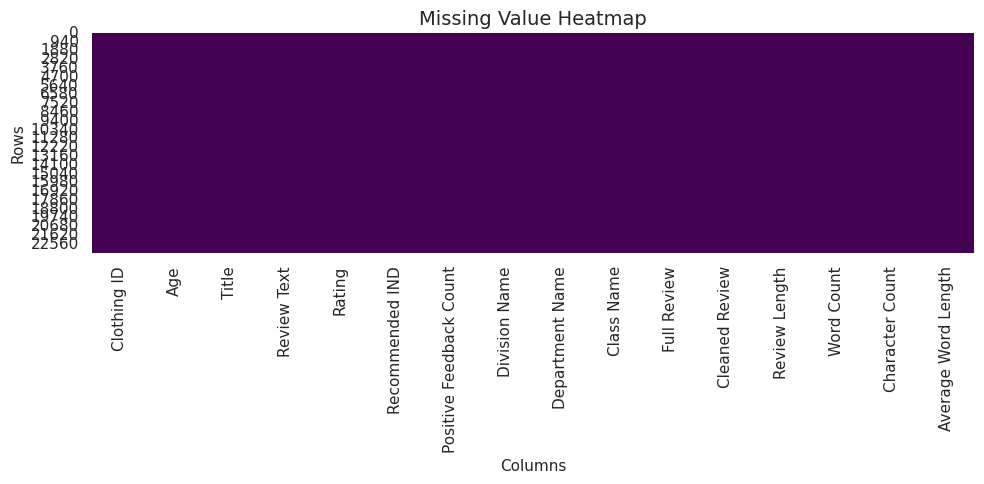

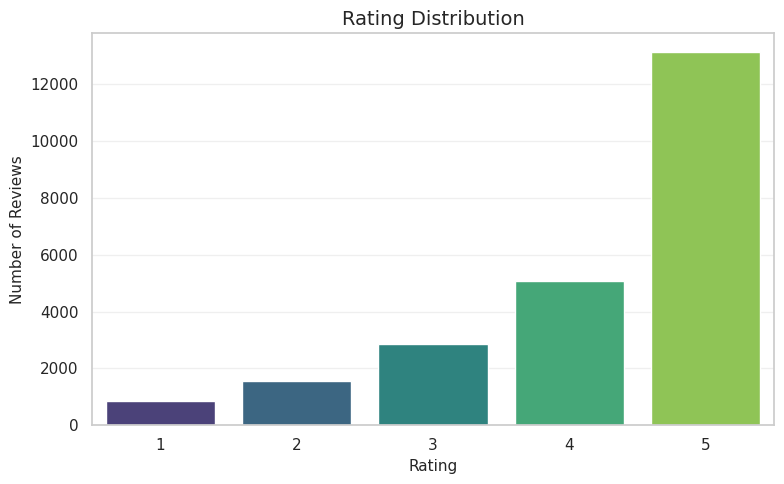

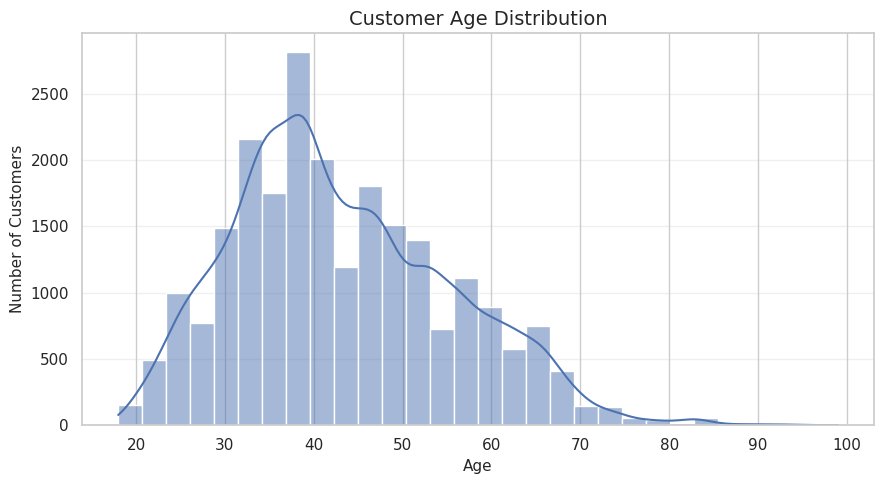

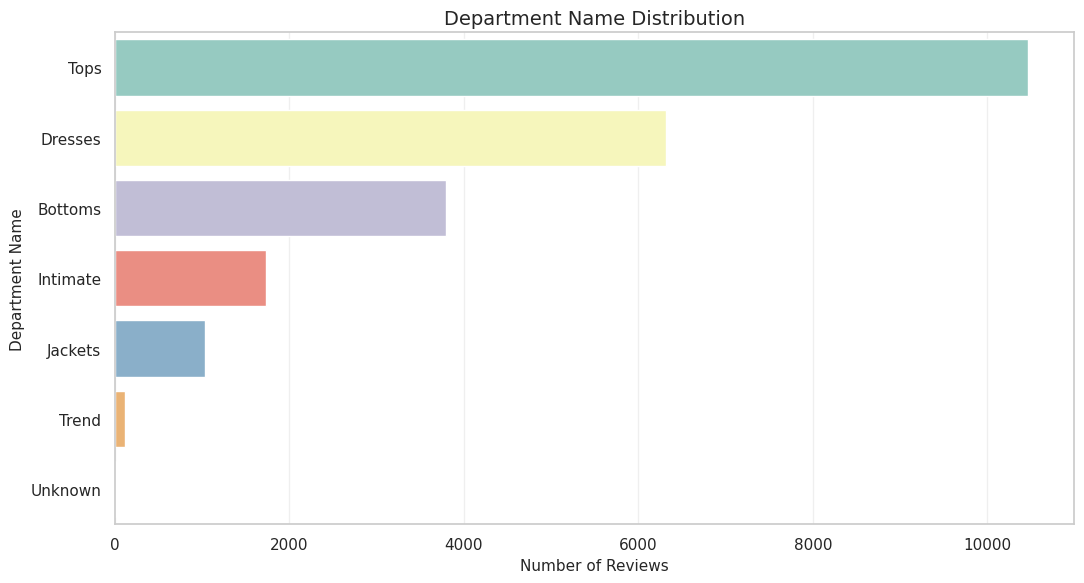

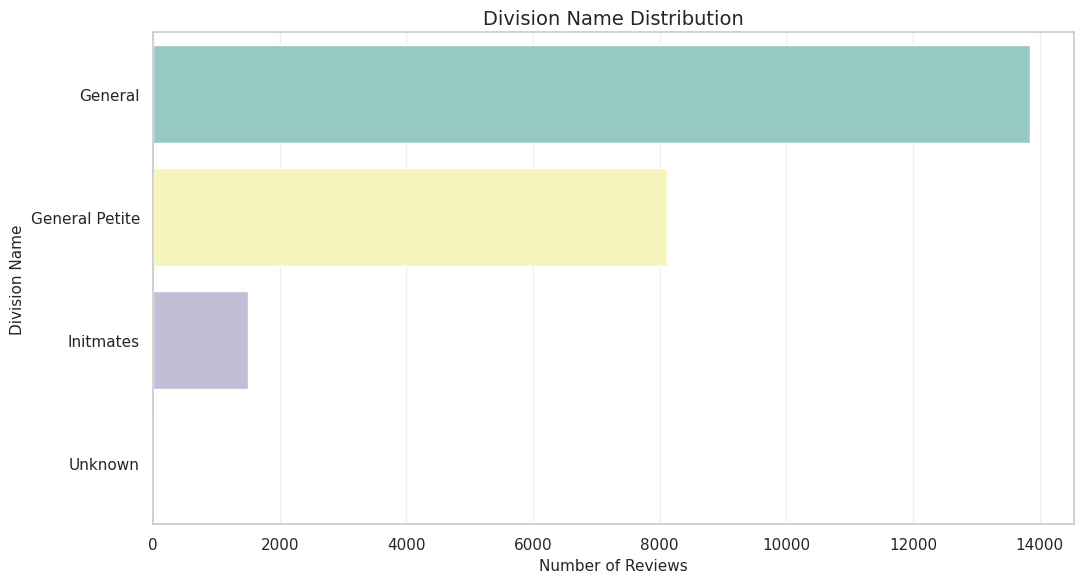

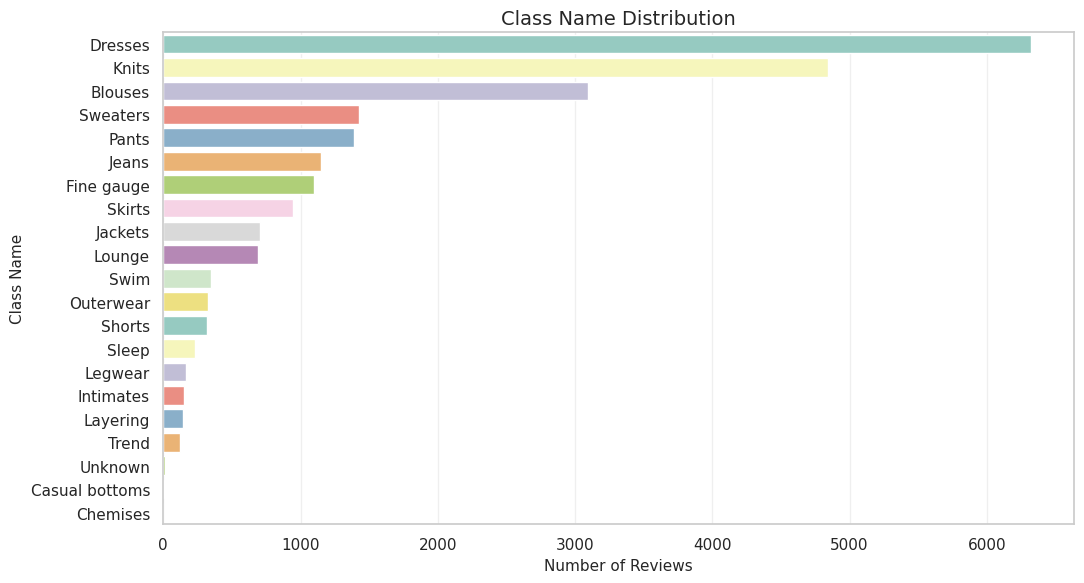

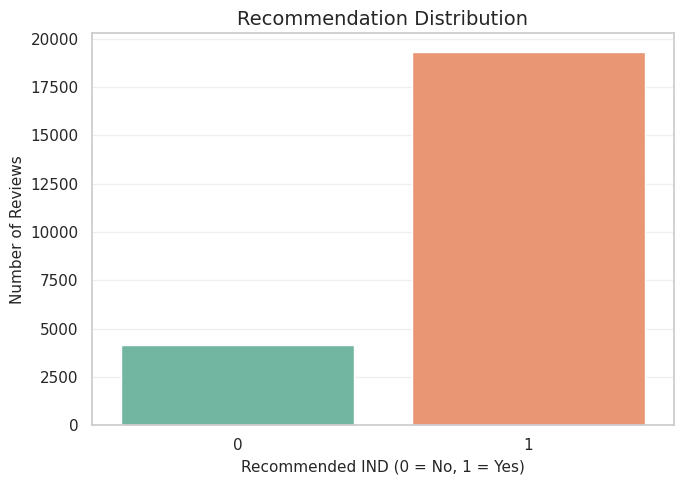

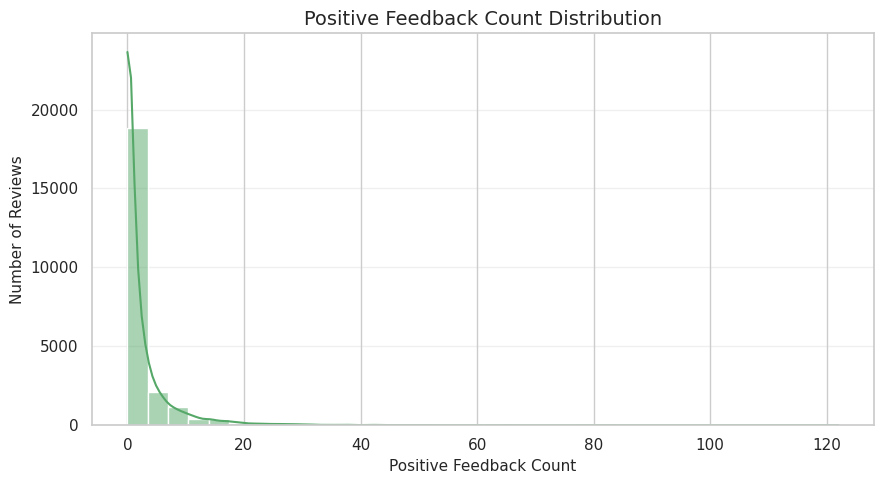

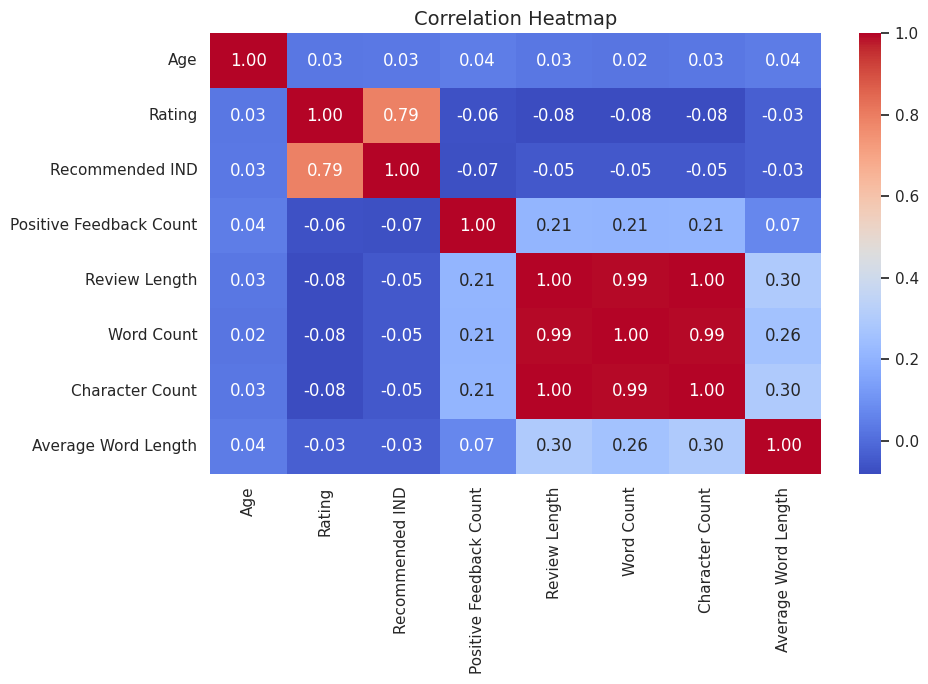

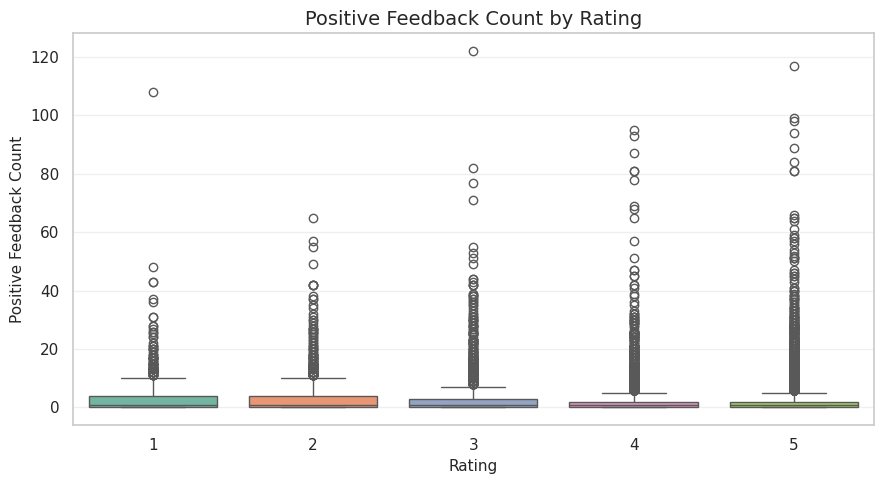

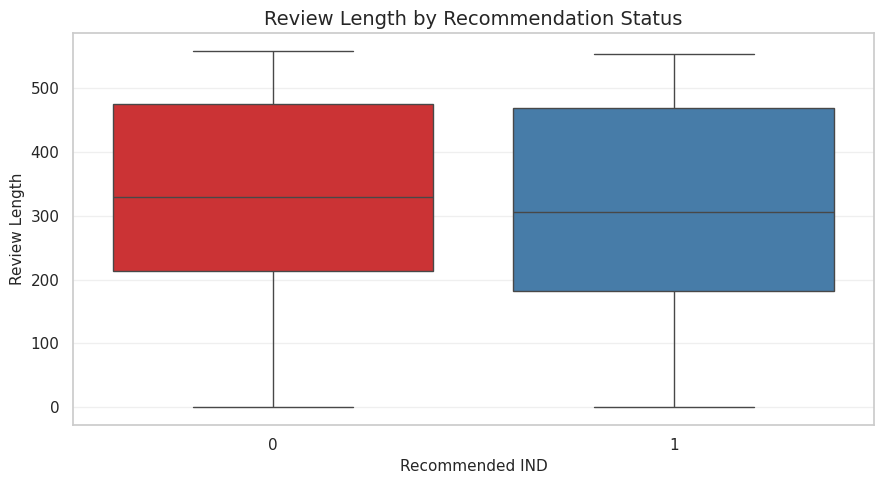

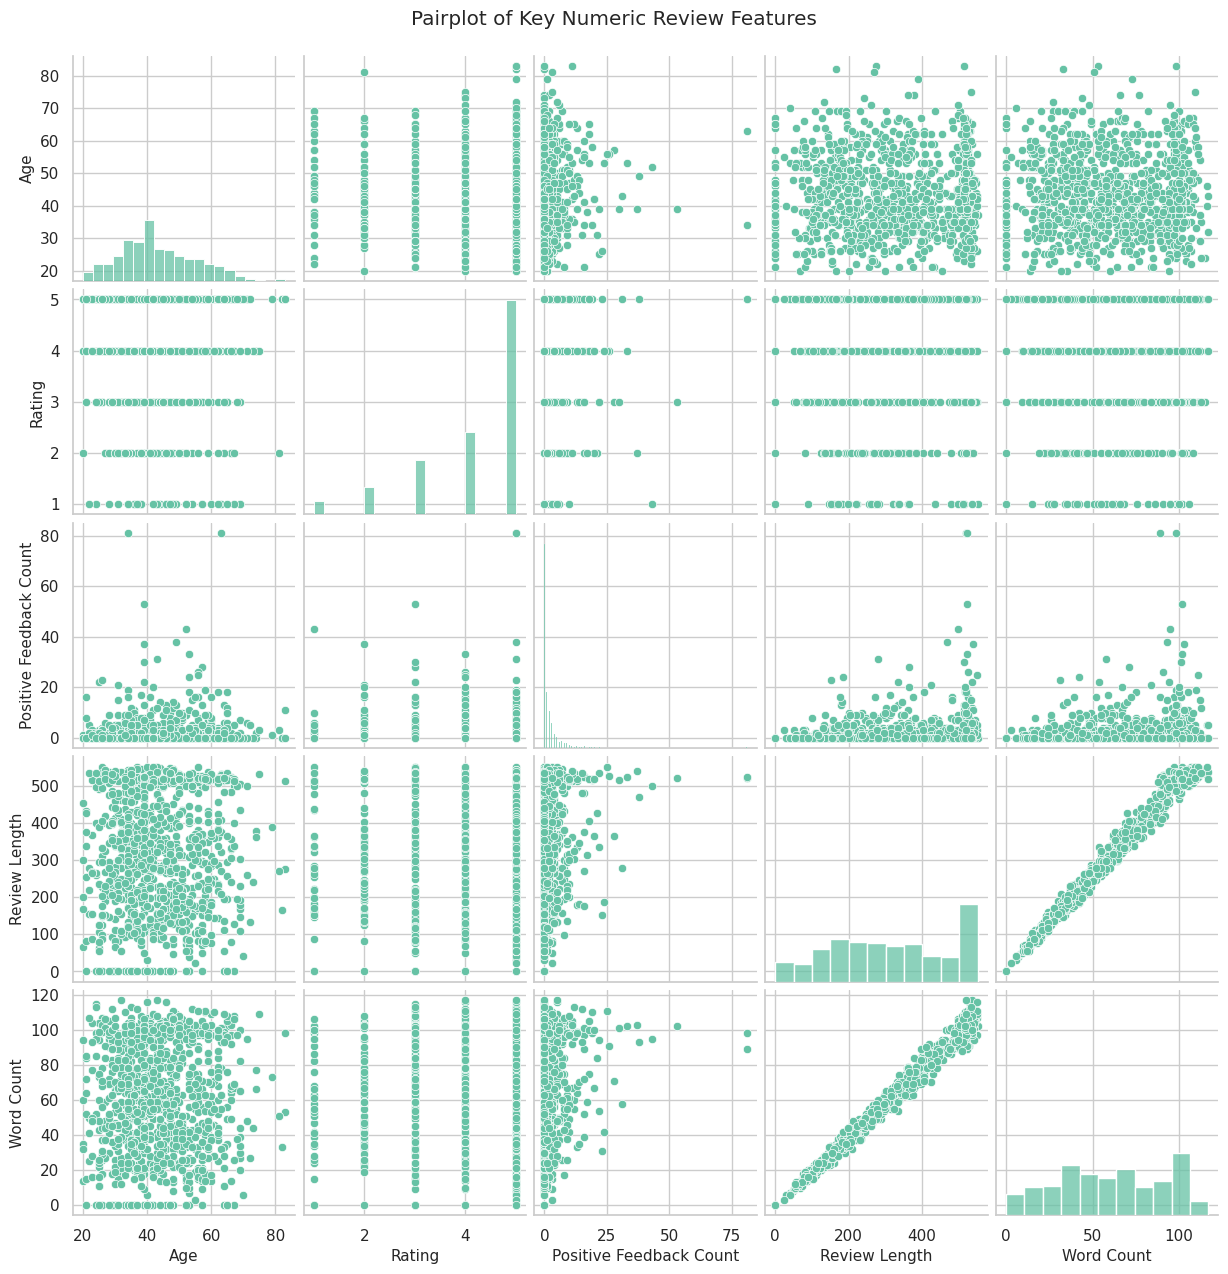

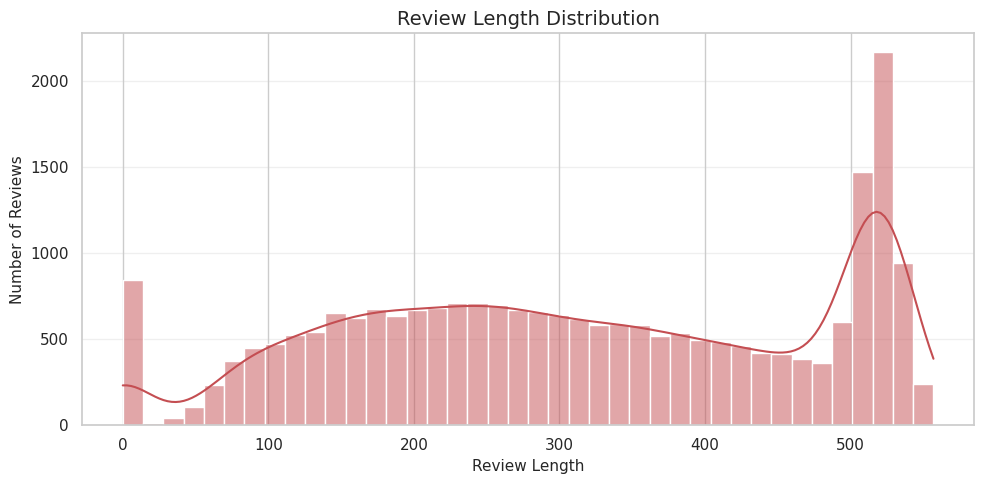

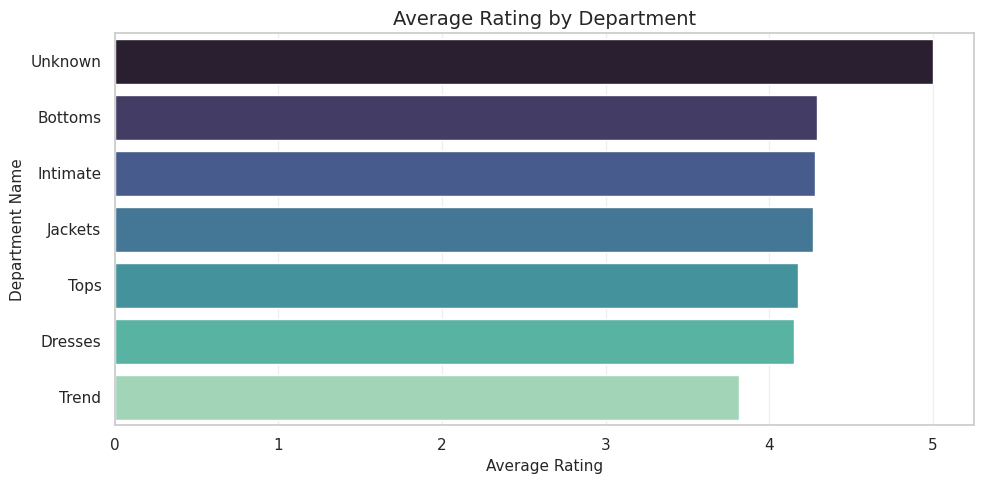

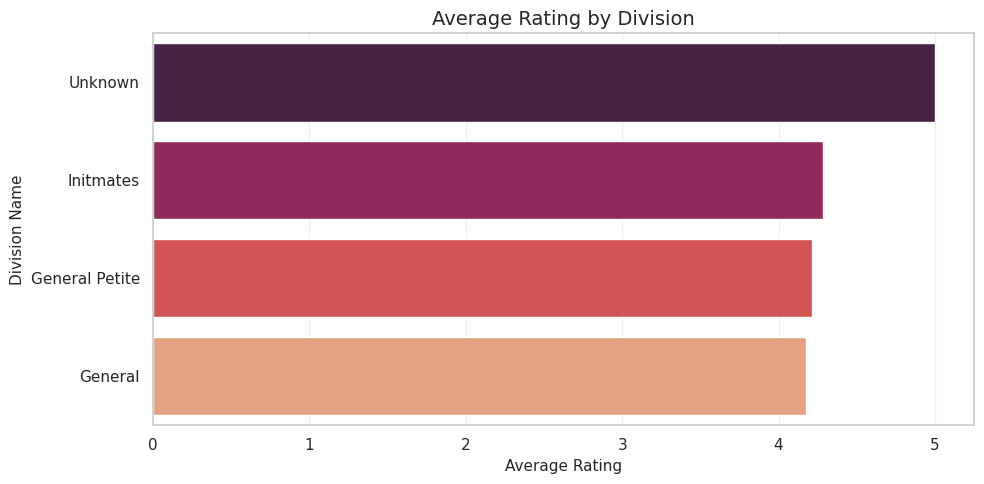


Recommendation percentage: 82.24%


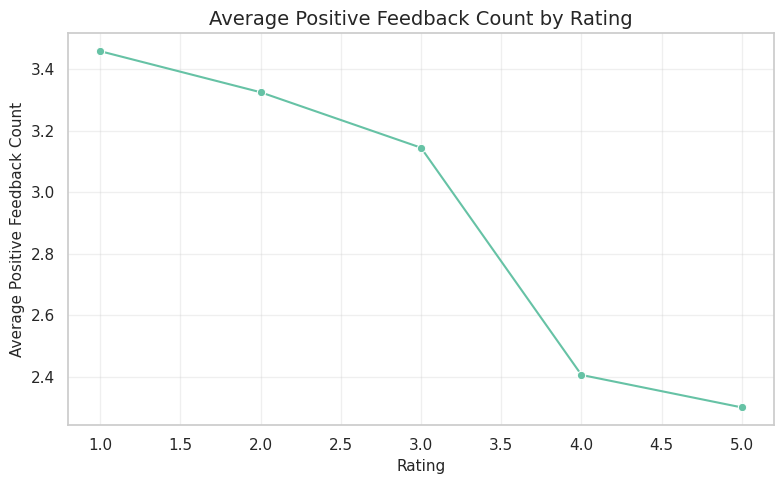

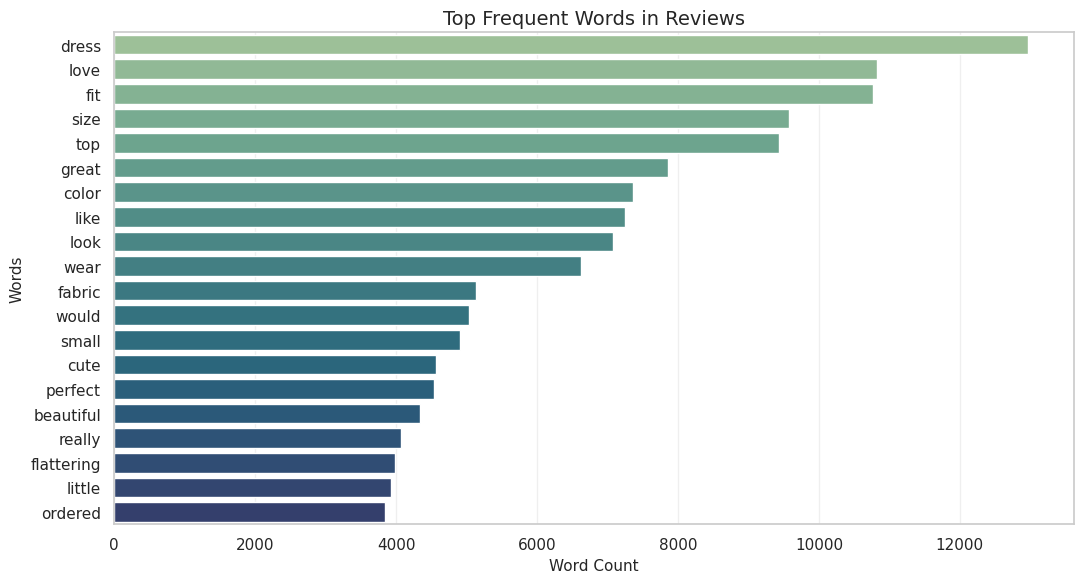

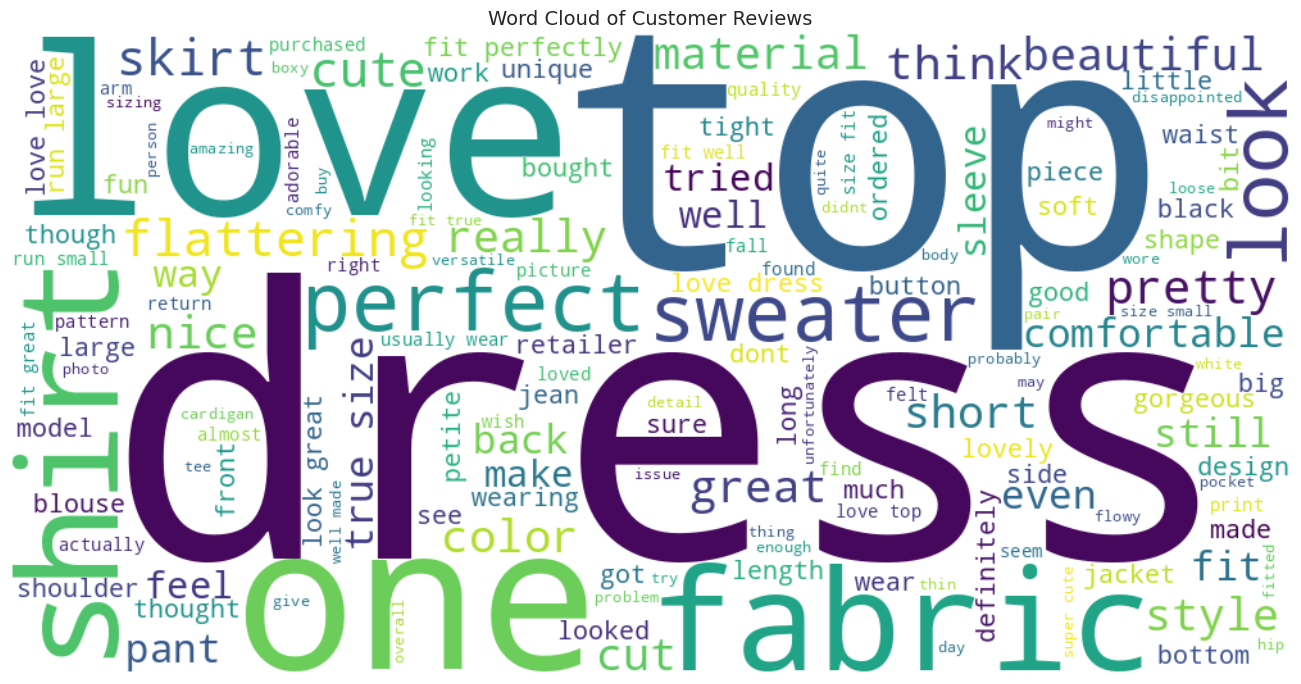

In [28]:
print("\nDataset overview:")
print(df.describe(include="all"))

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Rating", palette="viridis")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Age", bins=30, kde=True, color="#4C72B0")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for column, title in [
    ("Department Name", "Department Name Distribution"),
    ("Division Name", "Division Name Distribution"),
    ("Class Name", "Class Name Distribution"),
]:
    plt.figure(figsize=(11, 6))
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, palette="Set3")
    plt.title(title)
    plt.xlabel("Number of Reviews")
    plt.ylabel(column)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Recommended IND", palette="Set2")
plt.title("Recommendation Distribution")
plt.xlabel("Recommended IND (0 = No, 1 = Yes)")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Positive Feedback Count", bins=35, kde=True, color="#55A868")
plt.title("Positive Feedback Count Distribution")
plt.xlabel("Positive Feedback Count")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

numeric_for_corr = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Review Length",
    "Word Count",
    "Character Count",
    "Average Word Length",
]

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Rating", y="Positive Feedback Count", palette="Set2")
plt.title("Positive Feedback Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Positive Feedback Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Recommended IND", y="Review Length", palette="Set1")
plt.title("Review Length by Recommendation Status")
plt.xlabel("Recommended IND")
plt.ylabel("Review Length")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

sample_for_pairplot = df[numeric_for_corr].sample(
    n=min(1000, len(df)), random_state=42
)
sns.pairplot(
    sample_for_pairplot[
        ["Age", "Rating", "Positive Feedback Count", "Review Length", "Word Count"]
    ],
    diag_kind="hist",
)
plt.suptitle("Pairplot of Key Numeric Review Features", y=1.02)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Review Length", bins=40, kde=True, color="#C44E52")
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

department_rating = (
    df.groupby("Department Name")["Rating"].mean().sort_values(ascending=False)
)
plt.figure(figsize=(10, 5))
sns.barplot(x=department_rating.values, y=department_rating.index, palette="mako")
plt.title("Average Rating by Department")
plt.xlabel("Average Rating")
plt.ylabel("Department Name")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

division_rating = df.groupby("Division Name")["Rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=division_rating.values, y=division_rating.index, palette="rocket")
plt.title("Average Rating by Division")
plt.xlabel("Average Rating")
plt.ylabel("Division Name")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

recommendation_percentage = df["Recommended IND"].mean() * 100
print(f"\nRecommendation percentage: {recommendation_percentage:.2f}%")

feedback_by_rating = df.groupby("Rating")["Positive Feedback Count"].mean()
plt.figure(figsize=(8, 5))
sns.lineplot(x=feedback_by_rating.index, y=feedback_by_rating.values, marker="o")
plt.title("Average Positive Feedback Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Positive Feedback Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

all_words = " ".join(df["Cleaned Review"]).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=["Word", "Count"])

plt.figure(figsize=(11, 6))
sns.barplot(data=top_words, x="Count", y="Word", palette="crest")
plt.title("Top Frequent Words in Reviews")
plt.xlabel("Word Count")
plt.ylabel("Words")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

try:
    from wordcloud import WordCloud

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        colormap="viridis",
        max_words=150,
    ).generate(" ".join(df["Cleaned Review"]))

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Customer Reviews")
    plt.tight_layout()
    plt.show()
except Exception as error:
    print("Word cloud could not be generated:", error)


# Feature Engineering



Target variable distribution:
Recommended IND
1    19314
0     4172
Name: count, dtype: int64

Sentiment distribution:
Sentiment
Positive    18208
Neutral      2871
Negative     2407
Name: count, dtype: int64


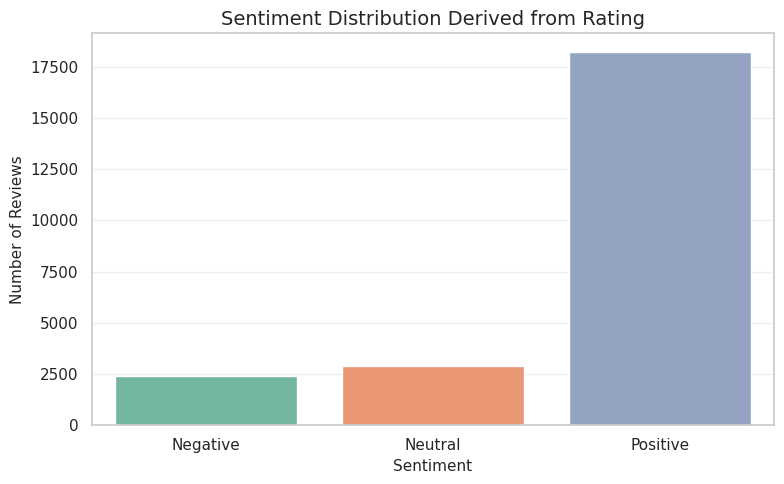

In [29]:
def rating_to_sentiment(rating):
    """Convert ratings into sentiment classes for business interpretation."""
    if rating >= 4:
        return "Positive"
    if rating == 3:
        return "Neutral"
    return "Negative"


df["Sentiment"] = df["Rating"].apply(rating_to_sentiment)
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"],
)
df["Has Positive Feedback"] = (df["Positive Feedback Count"] > 0).astype(int)
df["Long Review"] = (df["Review Length"] > df["Review Length"].median()).astype(int)

target_column = "Recommended IND"
X = df["Cleaned Review"].fillna("")
y = df[target_column].astype(int)

print("\nTarget variable distribution:")
print(y.value_counts())
print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Sentiment", order=["Negative", "Neutral", "Positive"], palette="Set2")
plt.title("Sentiment Distribution Derived from Rating")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Data Preprocessing


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=7000,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])



Training records: 18788
Testing records: 4698


# Feature Selection


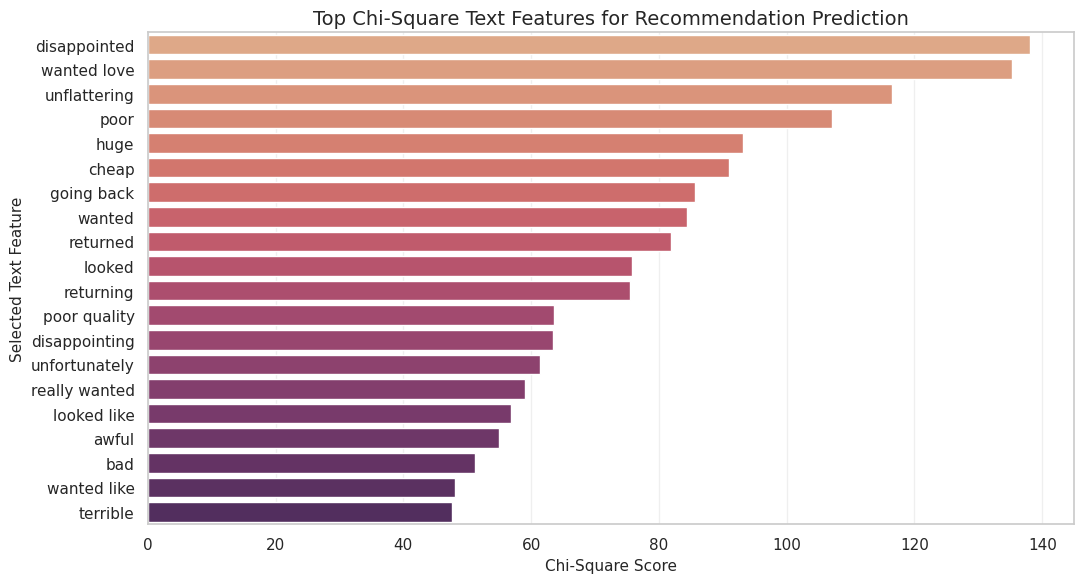


Top Chi-Square text features:
            Feature  Chi Square Score
233    disappointed        138.062061
1111    wanted love        135.266834
1085   unflattering        116.475370
771            poor        107.073673
483            huge         93.148517
130           cheap         90.953492
411      going back         85.659308
1108         wanted         84.337936
837        returned         81.876849
578          looked         75.772190
838       returning         75.510425
774    poor quality         63.523552
238   disappointing         63.437257
1088  unfortunately         61.364095
824   really wanted         59.094521
581     looked like         56.798705
50            awful         54.964172
60              bad         51.200595
1110    wanted like         48.055310
1017       terrible         47.643526


In [31]:
feature_selector = SelectKBest(score_func=chi2, k=1200)

feature_selection_pipeline = Pipeline(
    steps=[
        ("tfidf", tfidf_vectorizer),
        ("chi_square", feature_selector),
    ]
)

X_train_selected = feature_selection_pipeline.fit_transform(X_train, y_train)
selected_mask = feature_selection_pipeline.named_steps["chi_square"].get_support()
feature_names = feature_selection_pipeline.named_steps["tfidf"].get_feature_names_out()
selected_features = feature_names[selected_mask]
chi_scores = feature_selection_pipeline.named_steps["chi_square"].scores_[selected_mask]

top_chi_features = pd.DataFrame(
    {"Feature": selected_features, "Chi Square Score": chi_scores}
).sort_values("Chi Square Score", ascending=False).head(20)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_chi_features, x="Chi Square Score", y="Feature", palette="flare")
plt.title("Top Chi-Square Text Features for Recommendation Prediction")
plt.xlabel("Chi-Square Score")
plt.ylabel("Selected Text Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop Chi-Square text features:")
print(top_chi_features)


# Machine Learning


In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=42),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

model_pipelines = {
    model_name: Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(max_features=7000, min_df=3, max_df=0.85, ngram_range=(1, 2))),
            ("chi_square", SelectKBest(score_func=chi2, k=1200)),
            ("model", model),
        ]
    )
    for model_name, model in models.items()
}


# Model Evaluation



Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.86      0.73       835
           1       0.97      0.89      0.93      3863

    accuracy                           0.88      4698
   macro avg       0.80      0.88      0.83      4698
weighted avg       0.91      0.88      0.89      4698



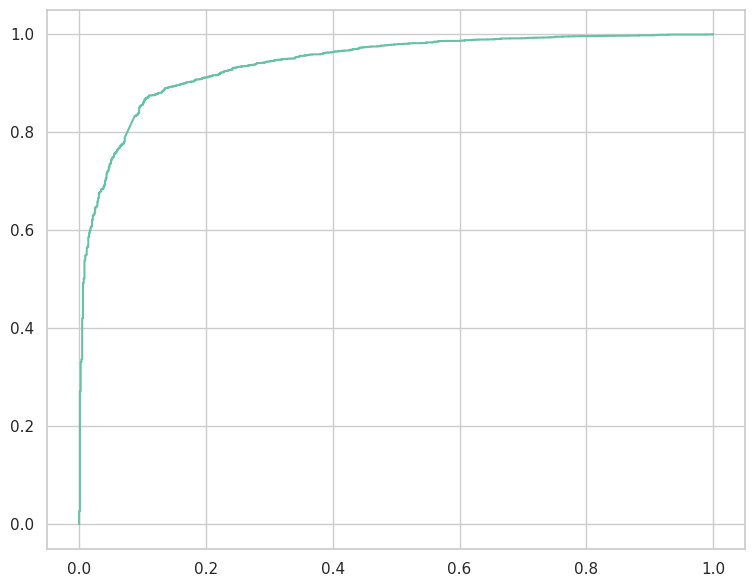

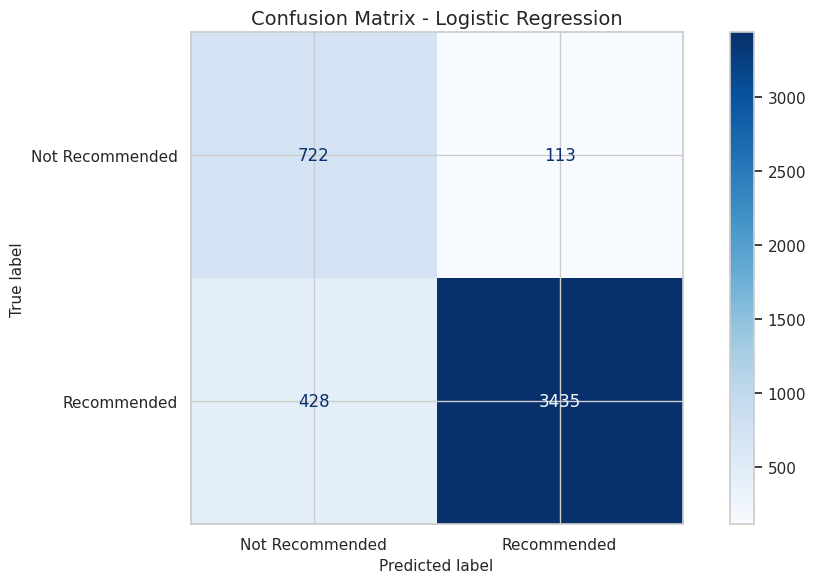


Multinomial Naive Bayes

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.33      0.47       835
           1       0.87      0.99      0.93      3863

    accuracy                           0.87      4698
   macro avg       0.87      0.66      0.70      4698
weighted avg       0.87      0.87      0.85      4698



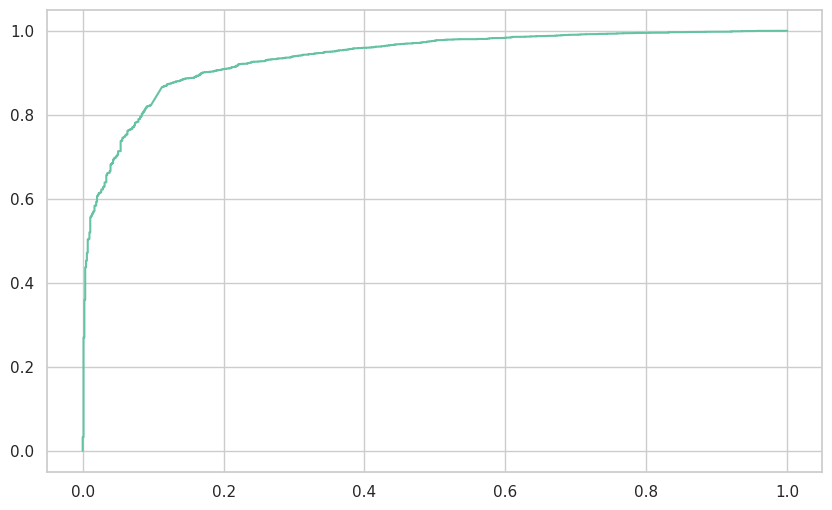

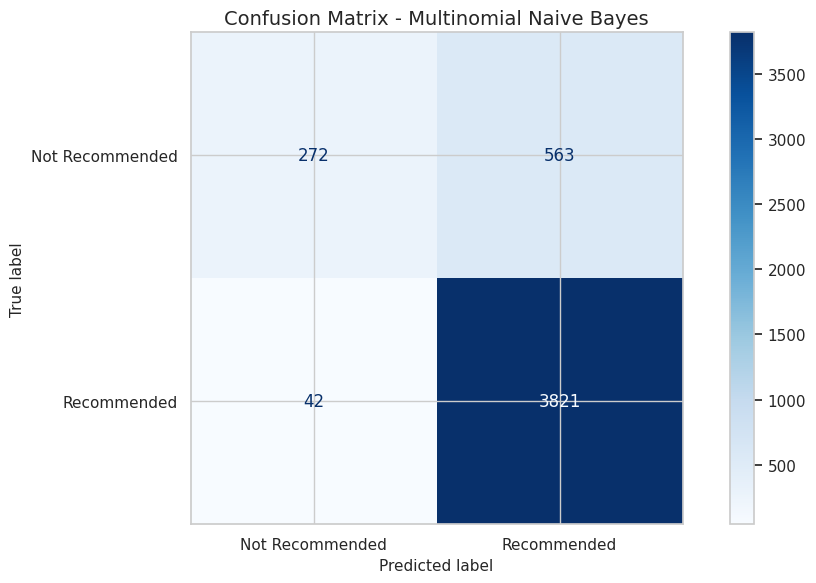


Linear SVM

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.84      0.72       835
           1       0.96      0.89      0.93      3863

    accuracy                           0.88      4698
   macro avg       0.80      0.87      0.82      4698
weighted avg       0.90      0.88      0.89      4698



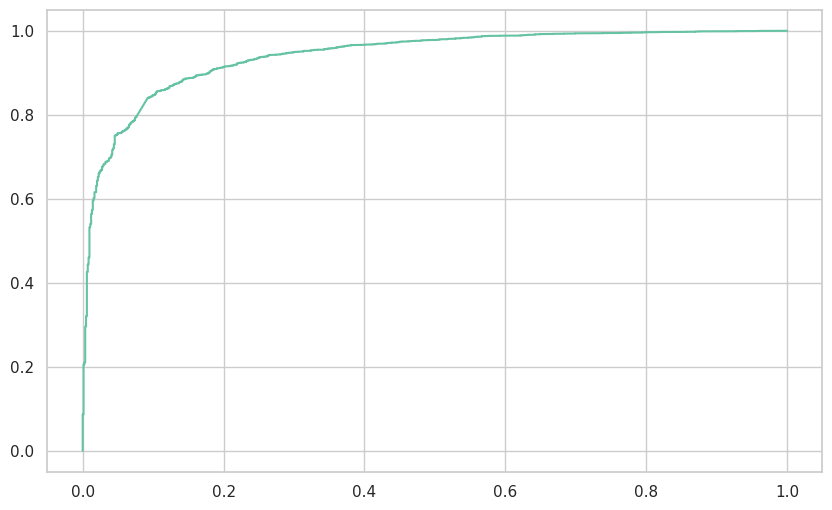

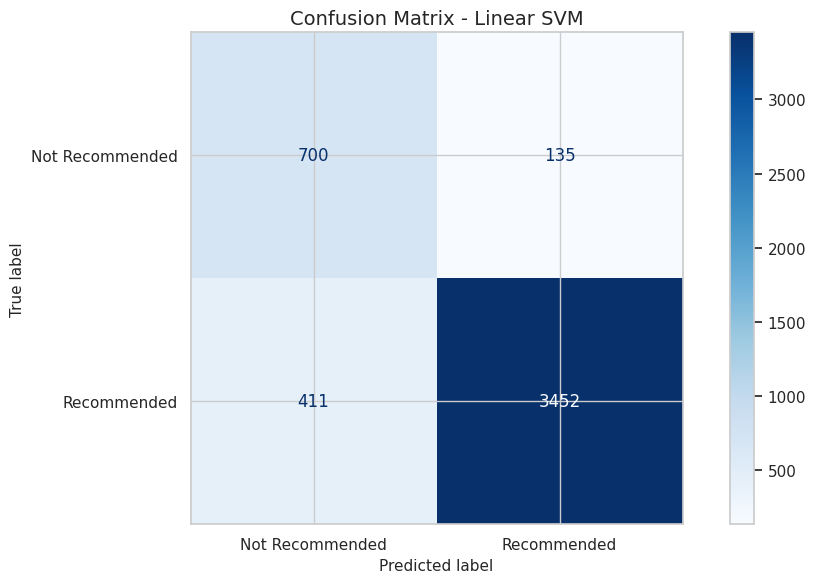


Random Forest Classifier

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.64      0.67       835
           1       0.92      0.95      0.93      3863

    accuracy                           0.89      4698
   macro avg       0.82      0.79      0.80      4698
weighted avg       0.89      0.89      0.89      4698



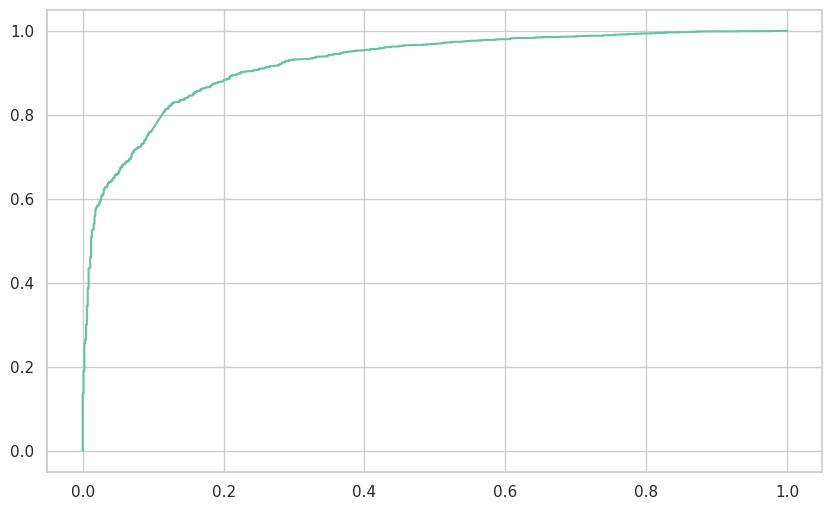

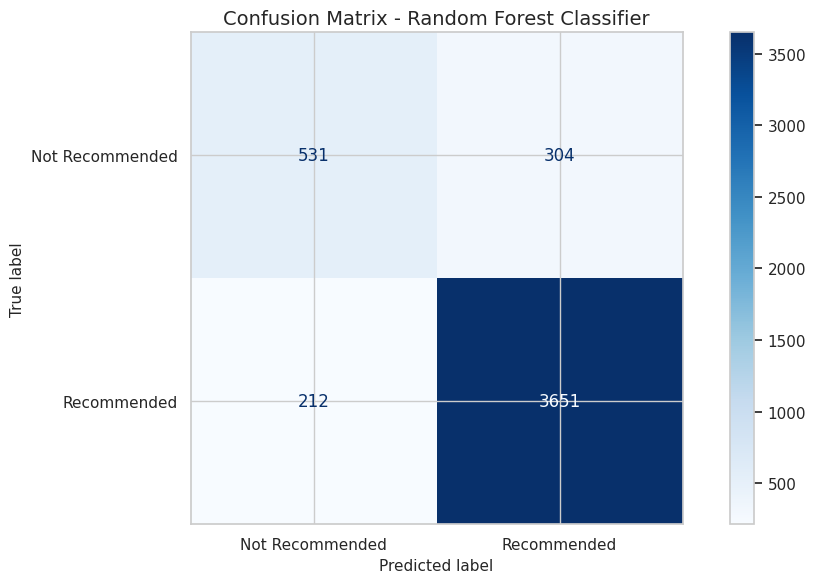

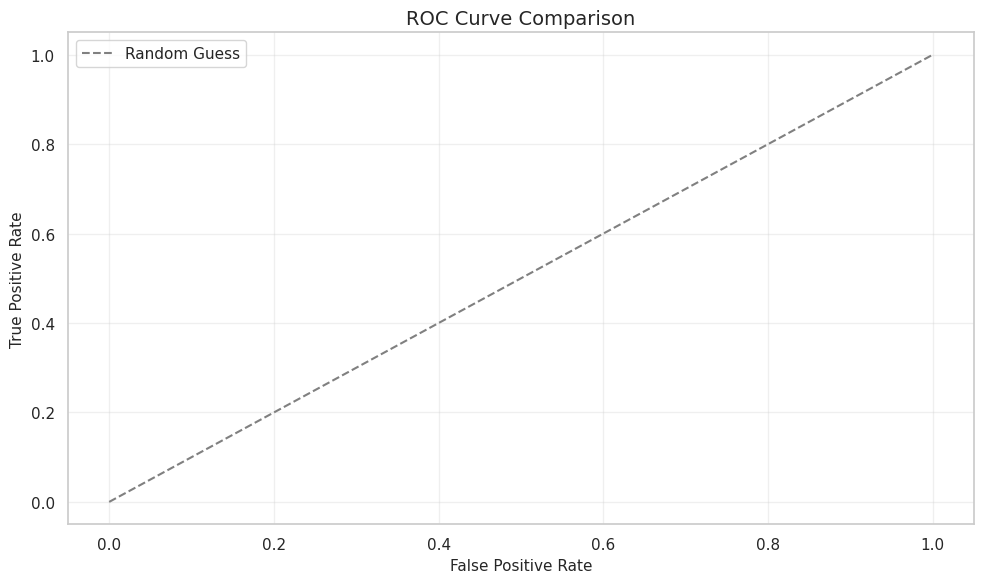


Model Comparison Table:
                      Model  Accuracy  Precision  Recall  F1 Score  AUC Score
3  Random Forest Classifier    0.8902     0.9231  0.9451    0.9340     0.9226
0       Logistic Regression    0.8848     0.9682  0.8892    0.9270     0.9411
2                Linear SVM    0.8838     0.9624  0.8936    0.9267     0.9413
1   Multinomial Naive Bayes    0.8712     0.8716  0.9891    0.9266     0.9366


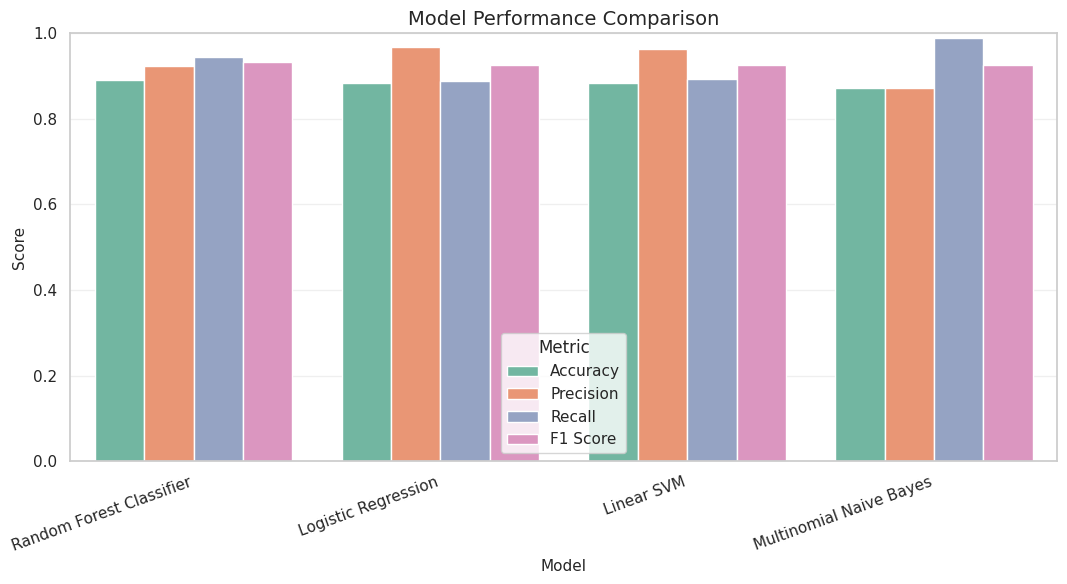


Best-performing model based on F1 Score: Random Forest Classifier


In [22]:
evaluation_rows = []
trained_models = {}

plt.figure(figsize=(9, 7))

for model_name, pipeline in model_pipelines.items():
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    trained_models[model_name] = pipeline

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    roc_auc = np.nan
    try:
        if hasattr(pipeline.named_steps["model"], "predict_proba"):
            y_score = pipeline.predict_proba(X_test)[:, 1]
        else:
            y_score = pipeline.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")
    except Exception as error:
        print("ROC curve could not be calculated:", error)

    evaluation_rows.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "AUC Score": roc_auc,
        }
    )

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Recommended", "Recommended"],
    ).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

model_comparison = pd.DataFrame(evaluation_rows).sort_values(
    by="F1 Score", ascending=False
)

print("\nModel Comparison Table:")
print(model_comparison.round(4))

plt.figure(figsize=(11, 6))
comparison_melted = model_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = model_comparison.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"\nBest-performing model based on F1 Score: {best_model_name}")


# Business Insights



Business Insights
Department with the highest average rating: Unknown (5.00)
Department with the lowest average rating: Trend (3.82)
Class with the lowest average rating: Trend (3.82)
Class with the highest average rating: Unknown (5.00)
Age group giving the lowest ratings: 26-35 (4.14)
Age group giving the highest ratings: 56-65 (4.30)

Most common appreciation words:
         Word  Count
0       dress  10125
1        love   9437
2         fit   8560
3        size   7665
4         top   7176
5       great   7001
6       color   5897
7        wear   5551
8        look   5060
9        like   4962
10    perfect   4258
11      small   3593
12       cute   3535
13  beautiful   3529
14     fabric   3432

Most common complaint words:
        Word  Count
0      dress   1267
1       like   1113
2       look    956
3        top    943
4        fit    888
5     fabric    789
6       size    778
7      would    730
8       back    620
9      color    590
10     small    561
11      love    529
1

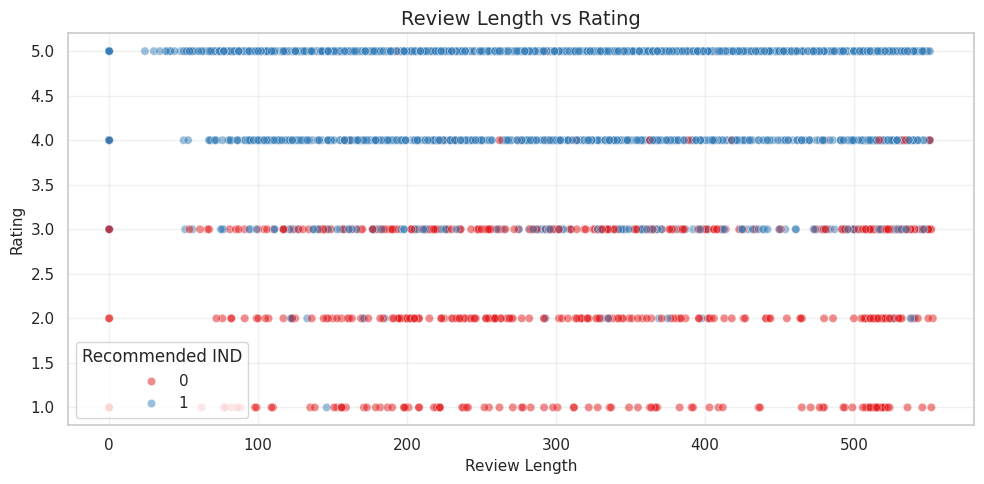

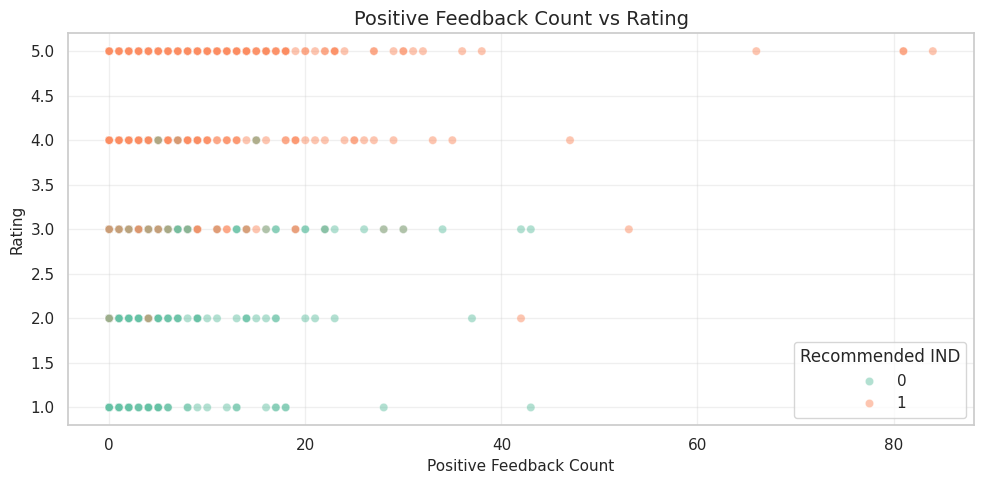

<Figure size 1100x600 with 0 Axes>

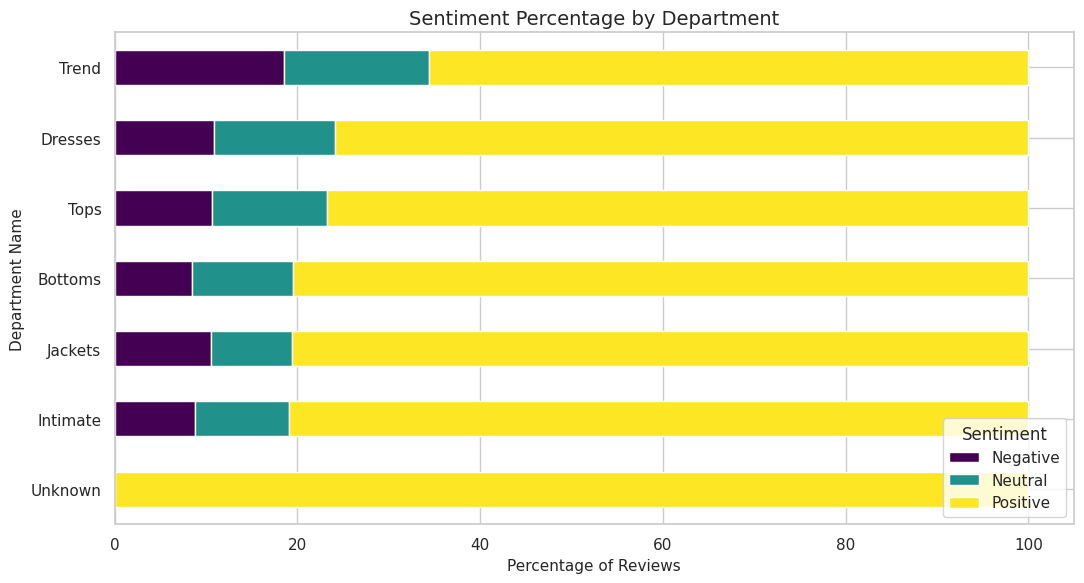


Most positively reviewed departments:
Department Name
Unknown     100.000000
Intimate     80.922190
Jackets      80.620155
Bottoms      80.494867
Tops         76.709973
Name: Positive, dtype: float64

Most negatively reviewed departments:
Department Name
Trend       18.487395
Dresses     10.903624
Tops        10.641956
Jackets     10.562016
Intimate     8.818444
Name: Negative, dtype: float64

Conclusion after business analysis: The review dataset shows strong overall customer recommendation behavior, but performance varies by department, class, age group, review length, and feedback engagement. Ratings and recommendation status are strongly aligned, making recommendation prediction a practical classification task for customer experience monitoring.


In [33]:
print("\nBusiness Insights")
print("=" * 80)

highest_department = department_rating.idxmax()
lowest_department = department_rating.idxmin()
print(
    f"Department with the highest average rating: {highest_department} "
    f"({department_rating.max():.2f})"
)
print(
    f"Department with the lowest average rating: {lowest_department} "
    f"({department_rating.min():.2f})"
)

class_rating = df.groupby("Class Name")["Rating"].mean().sort_values()
print(
    f"Class with the lowest average rating: {class_rating.index[0]} "
    f"({class_rating.iloc[0]:.2f})"
)
print(
    f"Class with the highest average rating: {class_rating.index[-1]} "
    f"({class_rating.iloc[-1]:.2f})"
)

age_group_rating = df.groupby("Age Group", observed=False)["Rating"].mean().sort_values()
print(
    f"Age group giving the lowest ratings: {age_group_rating.index[0]} "
    f"({age_group_rating.iloc[0]:.2f})"
)
print(
    f"Age group giving the highest ratings: {age_group_rating.index[-1]} "
    f"({age_group_rating.iloc[-1]:.2f})"
)

positive_reviews = df[df["Sentiment"] == "Positive"]["Cleaned Review"]
negative_reviews = df[df["Sentiment"] == "Negative"]["Cleaned Review"]

positive_words = Counter(" ".join(positive_reviews).split()).most_common(15)
negative_words = Counter(" ".join(negative_reviews).split()).most_common(15)

print("\nMost common appreciation words:")
print(pd.DataFrame(positive_words, columns=["Word", "Count"]))

print("\nMost common complaint words:")
print(pd.DataFrame(negative_words, columns=["Word", "Count"]))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.sample(n=min(3000, len(df)), random_state=42),
    x="Review Length",
    y="Rating",
    hue="Recommended IND",
    alpha=0.5,
    palette="Set1",
)
plt.title("Review Length vs Rating")
plt.xlabel("Review Length")
plt.ylabel("Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.sample(n=min(3000, len(df)), random_state=42),
    x="Positive Feedback Count",
    y="Rating",
    hue="Recommended IND",
    alpha=0.5,
    palette="Set2",
)
plt.title("Positive Feedback Count vs Rating")
plt.xlabel("Positive Feedback Count")
plt.ylabel("Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

department_sentiment = pd.crosstab(
    df["Department Name"], df["Sentiment"], normalize="index"
) * 100
department_sentiment = department_sentiment.sort_values(
    by="Positive", ascending=False
)

plt.figure(figsize=(11, 6))
department_sentiment[["Negative", "Neutral", "Positive"]].plot(
    kind="barh", stacked=True, colormap="viridis", figsize=(11, 6)
)
plt.title("Sentiment Percentage by Department")
plt.xlabel("Percentage of Reviews")
plt.ylabel("Department Name")
plt.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()

print("\nMost positively reviewed departments:")
print(department_sentiment["Positive"].sort_values(ascending=False).head())

print("\nMost negatively reviewed departments:")
print(department_sentiment["Negative"].sort_values(ascending=False).head())

print(
    "\nConclusion after business analysis: The review dataset shows strong overall "
    "customer recommendation behavior, but performance varies by department, class, "
    "age group, review length, and feedback engagement. Ratings and recommendation "
    "status are strongly aligned, making recommendation prediction a practical "
    "classification task for customer experience monitoring."
)


# Conclusion


In [37]:
print("\nFinal Conclusion")
print("=" * 80)
print(
    "This project cleaned and analyzed the Women's Clothing E-Commerce Reviews "
    "dataset, engineered NLP and customer behavior features, visualized review "
    "patterns, selected important TF-IDF text features using Chi-Square testing, "
    "and compared Logistic Regression, Multinomial Naive Bayes, Linear SVM, and "
    "Random Forest models for recommendation prediction."
)
print(
    f"The best model was {best_model_name}, based on the highest F1 Score in the "
    "model comparison table. The final insights can help the business identify "
    "high-performing departments, weaker product classes, common praise and "
    "complaint themes, and customer groups that need closer attention."
)



Final Conclusion
This project cleaned and analyzed the Women's Clothing E-Commerce Reviews dataset, engineered NLP and customer behavior features, visualized review patterns, selected important TF-IDF text features using Chi-Square testing, and compared Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest models for recommendation prediction.
The best model was Random Forest Classifier, based on the highest F1 Score in the model comparison table. The final insights can help the business identify high-performing departments, weaker product classes, common praise and complaint themes, and customer groups that need closer attention.
